# Explicit trajectory in magnetic field

## Lorentz forcce for a simple dipole 

Particles move in electric and magnetic field according to the Lorentz force law the forcce on a particle ${\bf F}$ is 

$$ 
\begin{equation}
F_{\rm Lorentz} = q \left({\bf E} + {\bf v} \times {\bf B} \right)
\end{equation}
$$

In a dipole magnet there is no electric field (${\bf E} =0$ and the magnetic field is in the vertical direction ${\bf B} = B_y \hat{{\bf j}}$, so the charged particle is only moving the $z$ direction

$$
\begin{equation}
F_{\rm dipole} = q {\rm v}\hat{{\bf k}}  \times {\bf B_{y} \hat{{\bf j}}} = q v B_y \hat{{\bf i}}
\end{equation}
$$

So the force is in the $x$ direction and proportional to $qvB_y$.

## Solving for motion

To solve for the position we need Newton's second law 

$$
\begin{equation}
{\bf F} = \frac{d{\bf p}}{dt}
\end{equation}
$$

where the momentum ${\bf} p$ is $\gamma m {\bf v}$. So assuming no acceleration 

$$
\begin{equation}
{\bf F} = \gamma m \frac{d {\bf v}}{dt}
\end{equation}
$$

Rearranging for $d{\bf v}/dt$ and integrating

$$
\begin{equation}
{\bf v} = \frac{{\bf F} \delta t}{m \gamma} + {\bf v}_0
\end{equation}
$$

Integrating again for position ${\bf r}$ as ${\bf v} = d{\bf r} /dt$ gives

$$
\begin{equation}
{\bf r} = \frac{{\bf F} \delta t^2}{2 m \gamma} + {\bf v}_0 \delta t + {\bf r}_0 
\tag{1}
\end{equation}
$$

The velocity can be approximated by 

$$
\begin{equation}
{\bf v} = \frac{{\bf r} - {\bf r_0}}{\delta t}
\end{equation}
$$

# Solving for ${\bf r}$ in python

Solving for the update equation, can be done in python by dividing the path into small steps. Here is an example of an update function 

In [16]:
import numpy as np

def coordinate_update(v, r, dt, B=1, gamma = 2e3, m = 9.11e-31) : 
    q = -1.6e-19 # electron
    B = np.array([0,B,0])        # 1 tesla
    F = q*np.cross(v,B)
    v1 = F*dt/(m*gamma) + v
    r1 = F*dt**2/(2*m*gamma) + v*dt + r
    return r1, v1

Here is example of using the update function. The initial position is $(0,0,0)$ and the velocity is $(0,0,c)$. The update is run 100 times for a time step of $\delta t = 1\times 10^{-11}$s. Each iteration the velocity and position is updated and used for the next iteration. The position and velocity are stored in lists which can be used for plotting. The magnetic field is set to 0.5 T

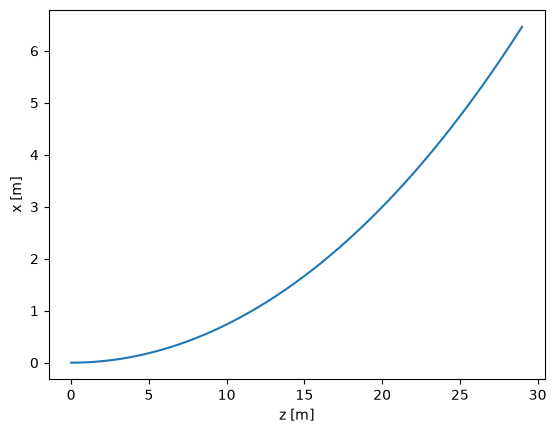

In [18]:
# initital position and velocity
r = np.array([0,0,0])
v = np.array([0,0,2.99792458e9])

# arrays to store position and velocity for plotting and analysis later
rarray = []
varray = [] 

# loop over time steps (1000 times) and compute new position and velocity
for i in range(1000) : 
    rarray.append(r)
    varray.append(v)
    r, v = coordinate_update(v,r, 1e-11, 0.5)

# convert lists to arrays for easier plotting 
rarray = np.array(rarray)
varray = np.array(varray)

# make plot
import matplotlib.pyplot as plt 
plt.plot(rarray[:,2], rarray[:,0],"-")
plt.xlabel("z [m]");
plt.ylabel("x [m]");

# Exercises

1. Explore the magnetic field $B$, relativistic factor $\gamma$ and mass $m$.
    1. Plot the trajectory for different variables
    2. Understand what angle the trajectory is bent by
1. Does a dipole magnet focus? So imagine taking two initial conditions that start at $\pm x_0$, where $x_0$ is a number.
2. Accelerator dipole magnets do not function over all space (limit the field below $z_{\rm max}$)
1. Try and make an update function which represents a quadrupole (or sextupole!)
    1. Remember for a dipole $B_y = \frac{dB}{dx} x$ (this is $g$ in the lecture notes).